In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
root = os.getcwd()

In [2]:
os.chdir(root+ '/evaluations/EGFR_MAPK/dream_cytof')
contexts = [
    'cytof_init', 
    'transcriptomics', 
    'proteomics']
regressors = [
    'linreg', 
    'lasso', 
    'elasticnet']

columns = [
    'regressor', 
    'context', 
    'train/test', 
    'rmse'
]

def res_to_rmse(df): 
    return np.sqrt(
        ((df['res'].values)**2).mean())

filename_template = "{samples}_{regressor}_{context}_{train_test}.csv"


rmse_dicts = []
for regressor in regressors:
    for context in contexts: 
        for train_test in [
            'train', 
            'test'
        ]:
            filename = filename_template.format(
                samples='0_5', 
                regressor=regressor,
                context=context, 
                train_test=train_test
            )
            if os.path.exists(filename): 
                rmse_dicts.append(
                    dict(
                        zip(
                            columns,
                            [
                                regressor, 
                                context, 
                                train_test, 
                                res_to_rmse(pd.read_csv(filename))                          
                            ]
                        )
                    )
                )    
rmse_df = pd.DataFrame.from_dict(rmse_dicts)

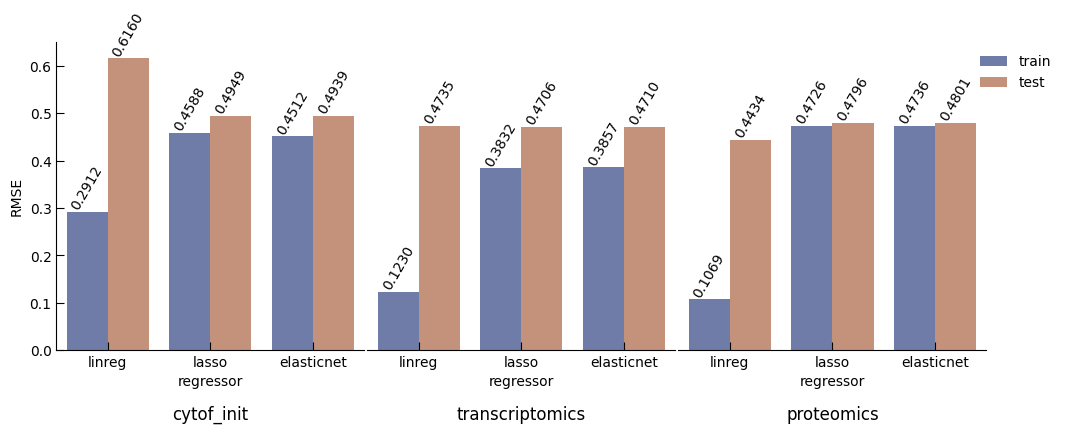

In [3]:
import seaborn as sns
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12,4))
gs = GridSpec(3, 3, figure=fig)

fig.subplots_adjust(wspace = 0.01)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[:, 1])
ax3 = fig.add_subplot(gs[:, 2])

for context, ax in zip(contexts, [ax1, ax2, ax3]): 
    g = sns.barplot(
        data=rmse_df[rmse_df['context'] == context],
        x="regressor", 
        y="rmse", 
        hue="train/test",
        palette = 'dark', alpha=.6, ax = ax,
    )
    for i in g.containers:
        g.bar_label(i, fmt='%.4f', rotation = 60)
    ax.set_title(context, y=-0.25)
    ax.set_ylim([0, 0.65])
    ax.tick_params(direction = 'in', length = 6)
    if ax != ax3: 
        ax.get_legend().remove()
    else: 
        ax.legend(bbox_to_anchor = [1.25, 1], frameon = False)
    if ax!= ax1: 
        ax.set_ylabel('')
        ax.tick_params(left = False, labelleft = False)
        for spine in ['left', 'top', 'right']:
            ax.spines[spine].set_visible(False)
    else: 
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.set_ylabel('RMSE')

plt.savefig('regressor_baseline.svg')
plt.savefig('regressor_baseline.png')

From Fabian's old runs:
- ```cytof_init```:
    - best_cytof_init_rmse_val = 0.4431 -- better than all regressors
    - [best_cytof_init_rmse_train = 0.42]
- ```'transcriptomics```:
    - best_transcriptomics_rmse_val = 0.473 -- worse than lasso and elasticnet
    - [best_transcriptomics_rmse_train = 0.346]
- ```proteomics```:
    - best_proteomics_rmse_val = 0.4467 -- doing worse than linear regression
    - [best_proteomics_rmse_train = 0.3041]